# Notebook 08 — Experiments (EXP_01 to EXP_10)

**Thesis:** RAG-Driven Natural Language Energy Demand Forecasting  
**Student:** Zoheb Anwar Hussain (1196931) | LJMU MSc UK 2026

---

| Group | Experiments | Purpose |
|---|---|---|
| A — Baseline & Core RAG | EXP_01 to EXP_04 | No-RAG, Dense, Hybrid, Hierarchical |
| B — Novelty 1: Attribution | EXP_05 to EXP_07 | Evidence IDs + citation checking |
| C — Novelty 2: Difficulty | EXP_08 to EXP_09 | Query difficulty prediction |
| D — Final Comparison | EXP_10 | Rank all methods |

**K values:** Each retrieval experiment runs at K = 3, 5, 10 (three runs each).

**Today:** EXP_01 (No-RAG baseline) — complete end-to-end.

---
### How to run individual experiments
Each section is independent. Jump to any section and run those cells.
Results are saved to `outputs/experiments/{EXP_ID}/` automatically.

---
## Setup

In [1]:
# ── Repo root on sys.path ────────────────────────────────────────────────────
import sys, logging
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── Gemini key check ─────────────────────────────────────────────────────────
from config.models import get_gemini_key, MODELS, EXP_DEFAULTS

try:
    gemini_key = get_gemini_key()
    print(f"Gemini key loaded  ({gemini_key[:8]}...)")
except EnvironmentError as e:
    print(f"{e}")

# ── Groq rotation client check ───────────────────────────────────────────────
from src.experiments.groq_client import RotatingGroqClient

try:
    _test_client = RotatingGroqClient()
    s = _test_client.stats
    print(f"\nGroq rotating client ready — {s['n_keys']} key(s) loaded")
    print(f"   Combined capacity  : ~{s['n_keys'] * 1000:,} requests/day")
    print(f"   Combined RPM       : ~{s['n_keys'] * 30} requests/minute")
    print()
    print("   Key index  | Available | Calls | Errors")
    print("   " + "-" * 42)
    for k in s["keys"]:
        avail = "yes" if k["available"] else "⏳ cooling"
        print(f"   Key {k['index']}      | {avail:9s} | {k['total_calls']:5d} | {k['total_errors']}")
except EnvironmentError as e:
    print(f"{e}")

print("\nModels:")
for k, v in MODELS.items():
    print(f"  {k:15s} = {v}")
print("\nExperiment defaults:")
for k, v in EXP_DEFAULTS.items():
    print(f"  {k:15s} = {v}")

Gemini key loaded  (AIzaSyBH...)

Groq rotating client ready — 12 key(s) loaded
   Combined capacity  : ~12,000 requests/day
   Combined RPM       : ~360 requests/minute

   Key index  | Available | Calls | Errors
   ------------------------------------------
   Key 1      | yes       |     0 | 0
   Key 2      | yes       |     0 | 0
   Key 3      | yes       |     0 | 0
   Key 4      | yes       |     0 | 0
   Key 5      | yes       |     0 | 0
   Key 6      | yes       |     0 | 0
   Key 7      | yes       |     0 | 0
   Key 8      | yes       |     0 | 0
   Key 9      | yes       |     0 | 0
   Key 10      | yes       |     0 | 0
   Key 11      | yes       |     0 | 0
   Key 12      | yes       |     0 | 0

Models:
  gemini_kb       = gemini-2.0-flash-preview
  gemini_gd       = gemini-2.5-flash
  embedding       = sentence-transformers/all-MiniLM-L6-v2
  groq_rag        = llama-3.3-70b-versatile
  groq_judge      = llama-3.3-70b-versatile

Experiment defaults:
  top_k_values    = [

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# ── Output dirs ───────────────────────────────────────────────────────────────
OUTPUTS_DIR     = Path("outputs")
EXP_OUTPUTS_DIR = Path("outputs") / "experiments" 
EXP_OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.INFO,
                    format="%(levelname)s | %(name)s | %(message)s")

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
print("Setup complete")

Setup complete


In [3]:
# ── Load golden dataset (queries for all experiments) ────────────────────────
# Try both common save locations from Notebook 02
GOLDEN_PATHS = [
    OUTPUTS_DIR / "golden_dataset" / "combined_golden_dataset.csv",
    REPO_ROOT  / "outputs" / "golden_dataset" / "combined_golden_dataset.csv",
]

golden_df = None
for p in GOLDEN_PATHS:
    if p.exists():
        golden_df = pd.read_csv(p)
        print(f"   Golden dataset loaded from {p}")
        print(f"   Shape: {golden_df.shape}")
        print(f"   Columns: {golden_df.columns.tolist()}")
        break

if golden_df is None:
    print("   Golden dataset not found at any expected path.")
    print("   Run Notebook 02 first, or manually set the path below.")

golden_df.head(3)

   Golden dataset loaded from E:\UpGrad\LJMU_Thesis\Topic_1_Energy_Forecasting\Research_Proposal\Git_Repo\RAG-Based-Energy-Forecasting\outputs\golden_dataset\combined_golden_dataset.csv
   Shape: (50, 18)
   Columns: ['golden_id', 'dataset_source', 'query_type', 'difficulty_level', 'query_scope', 'granularity_target', 'user_query', 'expected_summary_ids', 'expected_primary_summary_id', 'expected_context_summary', 'reference_answer', 'answer_must_include', 'answer_must_not_include', 'retrieval_strategy_target', 'retrieval_notes', 'evaluation_notes', 'generated_at', 'generated_by']


,golden_id,dataset_source,query_type,difficulty_level,query_scope,granularity_target,user_query,expected_summary_ids,expected_primary_summary_id,expected_context_summary,reference_answer,answer_must_include,answer_must_not_include,retrieval_strategy_target,retrieval_notes,evaluation_notes,generated_at,generated_by
0,1,gefcom,statistical,easy,daily,daily,What was the average daily electricity load an...,"[""gefcom_daily_18_2005-08-07"", ""gefcom_daily_3...",gefcom_daily_18_2005-08-07,[gefcom_daily_18_2005-08-07] (gefcom/daily):\n...,"Across the GEFCom zones and dates provided, th...","[""MW"", ""average"", ""load""]","[""Sub_metering"", ""voltage"", ""household""]",dense,Should retrieve daily summary rows containing ...,Accept if MW values and daily averages are ref...,28-04-2026 13:31:51,gemini-2.5-flash
1,2,gefcom,statistical,easy,daily,daily,What is the typical range of minimum and maxim...,"[""gefcom_daily_18_2005-08-07"", ""gefcom_daily_3...",gefcom_daily_18_2005-08-07,[gefcom_daily_18_2005-08-07] (gefcom/daily):\n...,Across the GEFCom zones for which data is avai...,"[""MW"", ""minimum"", ""maximum""]","[""household"", ""Sub_metering"", ""watt""]",dense,Tests retrieval of load_min and load_max from ...,Answer must reference both min and max values ...,28-04-2026 13:32:06,gemini-2.5-flash
2,3,gefcom,statistical,medium,monthly,monthly,Which months show the highest average electric...,"[""gefcom_monthly_15.0_February_2008"", ""gefcom_...",gefcom_monthly_15.0_February_2008,[gefcom_monthly_15.0_February_2008] (gefcom/mo...,The provided knowledge base summaries only con...,"[""month"", ""demand"", ""MW""]","[""household"", ""Sub_metering""]",dense,Should retrieve monthly aggregate summaries an...,Accept if specific months are named with suppo...,28-04-2026 13:32:45,gemini-2.5-flash


In [5]:
# ── Standardise column names ─────────────────────────────────────────────────
# Golden dataset uses 'user_query' and 'reference_answer'
col_map = {}

# Question column — try in order of likelihood
for candidate in ["user_query", "query", "question_text"]:
    if candidate in golden_df.columns and "question" not in golden_df.columns:
        col_map[candidate] = "question"
        break

# Ground truth column
for candidate in ["reference_answer", "answer", "ground_truth_text"]:
    if candidate in golden_df.columns and "ground_truth" not in golden_df.columns:
        col_map[candidate] = "ground_truth"
        break

if col_map:
    golden_df = golden_df.rename(columns=col_map)
    print(f"Renamed columns: {col_map}")

# Add query_id if missing
if "query_id" not in golden_df.columns:
    golden_df["query_id"] = [f"q{i:03d}" for i in range(len(golden_df))]

QUERIES = golden_df.to_dict(orient="records")
print(f"\nTotal queries ready for experiments: {len(QUERIES)}")
print(f"\nSample question: {QUERIES[0].get('question', '')[:120]}")
print(f"Sample ground truth: {QUERIES[0].get('ground_truth', '')[:120]}")


Total queries ready for experiments: 50

Sample question: What was the average daily electricity load and peak load recorded across GEFCom zones during the dataset period?
Sample ground truth: Across the GEFCom zones and dates provided, the average hourly electricity loads varied. On Sunday, August 7, 2005, Zone


In [6]:
from groq_key_checker import check_all_keys
check_all_keys()

INFO | config.groq_keys | Loaded 12 Groq API key(s).



  GROQ KEY STATUS  —  02 May 2026  18:26:36 IST
  TPD resets at 05:30 IST  (11.1 hrs from now)  │  12 keys loaded



INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


...

INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


  ─────────────────────────────────────────────────────────────────────────────────────────────────────
  Key ID                      Used Tokens      Remaining Tokens    Reset (IST)     Status              
  ─────────────────────────────────────────────────────────────────────────────────────────────────────
  gsk_tH2r...RnjS             < 100,000        > 0 (fresh)         05:30 IST       🟢 Available         
  gsk_C0Et...dZ38             < 100,000        > 0 (fresh)         05:30 IST       🟢 Available         
  gsk_MytK...uZP9             < 100,000        > 0 (fresh)         05:30 IST       🟢 Available         
  gsk_JlDY...ECa8             < 100,000        > 0 (fresh)         05:30 IST       🟢 Available         
  gsk_Ol9X...R901             < 100,000        > 0 (fresh)         05:30 IST       🟢 Available         
  gsk_jXQz...V7if             < 100,000        > 0 (fresh)         05:30 IST       🟢 Available         
  gsk_iv4B...193J             < 100,000        > 0 (fresh)      

[{'idx': 1,
  'preview': 'gsk_tH2r...RnjS',
  'status': 'ok',
  'tpd_used': None,
  'tpd_rem': None,
  'retry_in': None},
 {'idx': 2,
  'preview': 'gsk_C0Et...dZ38',
  'status': 'ok',
  'tpd_used': None,
  'tpd_rem': None,
  'retry_in': None},
 {'idx': 3,
  'preview': 'gsk_MytK...uZP9',
  'status': 'ok',
  'tpd_used': None,
  'tpd_rem': None,
  'retry_in': None},
 {'idx': 4,
  'preview': 'gsk_JlDY...ECa8',
  'status': 'ok',
  'tpd_used': None,
  'tpd_rem': None,
  'retry_in': None},
 {'idx': 5,
  'preview': 'gsk_Ol9X...R901',
  'status': 'ok',
  'tpd_used': None,
  'tpd_rem': None,
  'retry_in': None},
 {'idx': 6,
  'preview': 'gsk_jXQz...V7if',
  'status': 'ok',
  'tpd_used': None,
  'tpd_rem': None,
  'retry_in': None},
 {'idx': 7,
  'preview': 'gsk_iv4B...193J',
  'status': 'ok',
  'tpd_used': None,
  'tpd_rem': None,
  'retry_in': None},
 {'idx': 8,
  'preview': 'gsk_z86J...eW93',
  'status': 'ok',
  'tpd_used': None,
  'tpd_rem': None,
  'retry_in': None},
 {'idx': 9,
  'preview':

In [7]:
from experiments.ragas_evaluator import (
    run_ragas_for_experiment,
    run_ragas_for_all_k,
    load_ragas_scores,
    summarise_ragas_scores,
    RAGAS_METRIC_COLS,
)
import os

print('    RAGAS evaluator loaded')
print(f'   Batch size  : 5 queries per batch')
print(f'   Batch delay : 30s between batches')
print(f'   Key rotation: round-robin across all 12 Groq keys')

    RAGAS evaluator loaded
   Batch size  : 5 queries per batch
   Batch delay : 30s between batches
   Key rotation: round-robin across all 12 Groq keys


---
## EXP_01 — No-RAG LLM Baseline

**Objective:** Direct LLM generation with no retrieval.  
**Purpose:** Proves whether RAG adds grounding value over a raw LLM.  
**Note:** No K parameter — runs once over all 50 queries.

In [8]:
from experiments.exp_01_no_rag_variants import run_all_variants, build_comparison_table

print("Running EXP_01 — 5 Prompting Strategy Variants...")
print(f"  Queries  : {len(QUERIES)}")
print(f"  Variants : Zero-Shot | Role | Few-Shot | Chain-of-Thought | Structured")
print(f"  Model    : {MODELS['groq_rag']} (Groq)")
print()

exp01_results = run_all_variants(
    queries=QUERIES,
    outputs_dir=EXP_OUTPUTS_DIR,
)

INFO | config.groq_keys | Loaded 12 Groq API key(s).


Running EXP_01 — 5 Prompting Strategy Variants...
  Queries  : 50
  Variants : Zero-Shot | Role | Few-Shot | Chain-of-Thought | Structured
  Model    : llama-3.3-70b-versatile (Groq)



INFO | src.experiments.groq_client | RotatingGroqClient ready — 12 key(s) loaded.
INFO | src.experiments.groq_client | Key pool: 12 available, 12 total. Cooldown=62s  MaxRetries=8
INFO | experiments.exp_01_no_rag_variants | ─── Running EXP_01A_ZERO_SHOT ───



  EXP_01A_ZERO_SHOT
  Strategy : Zero Shot
  Queries  : 50
  Model    : llama-3.3-70b-versatile


INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO | datasets | TensorFlow version 2.18.0 available.
INFO | datasets | JAX version 0.4.38 available.
INFO | sentence_transformers.base.model | No device provided, using cpu
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
INFO | httpx | HTTP R

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO | experiments.runner | [EXP_01E_STRUCTURED | k=0] Complete — 50 queries, 0 errors, 93.5s
INFO | experiments.exp_01_no_rag_variants | [EXP_01E_STRUCTURED] complete — 50 queries, 0 errors
INFO | experiments.exp_01_no_rag_variants | [EXP_01E_STRUCTURED] variant_observation: Structured Output Prompting: 50/50 answers contained all four required sections (OBSERVATION / PATTERN / IMPLICATION / CONFIDENCE). Self-reported confidence distribution — High: 14, Medium: 36. 0/50 answers cited numerical values. The forced CONFIDENCE field provides a novel self-assessment signal that can be correlated against computed hallucination rates — if the model's self-reported Low confidence aligns with higher hallucination, it supports the Novelty 2 (query difficulty prediction) thesis argument.
INFO | src.experiments.groq_client | RotatingGroqClient stats — total_requests=250  429s=0  rotations=0
INFO | src.experiments.groq_client |   Key 1 ✅  calls=21  errors=0  rpm_remaining=None  tpm_remaining=None



  ✅ EXP_01E_STRUCTURED complete
     Queries   : 50
     Errors    : 0
     Time      : 93.5s
     Useful %  : 100.0%
     Ans Rel.  : 0.7833
     Sem Sim.  : 0.724
     Halluc.   : 1.0
     Clarity   : 0.3651

  📝 Observation:
     50/50 answers passed the usefulness threshold (relevance >= 0.40, >= 20 words). 0/50 answers cited specific numerical values. 0/50 answers included uncertainty/hedging language.

  📊 Variant Analysis:
     Structured Output Prompting: 50/50 answers contained all four required sections (OBSERVATION / PATTERN / IMPLICATION / CONFIDENCE). Self-reported confidence distribution — High: 14, Medium: 36. 0/50 answers cited numerical values. The forced CONFIDENCE field provides a novel self-assessment signal that can be correlated against computed hallucination rates — if the model's self-reported Low confidence aligns with higher hallucination, it supports the Novelty 2 (query difficulty prediction) thesis argument.


In [9]:
print("EXP_01 — All Variants Summary:")
print("=" * 60)
for exp_id, result in exp01_results.items():
    m = result.agg_metrics
    print(f"\n  {exp_id}")
    print(f"    Useful %         : {m.get('pct_useful', 0)*100:.1f}%")
    print(f"    Answer Relevance : {m.get('avg_answer_relevance')}")
    print(f"    Semantic Sim.    : {m.get('avg_semantic_similarity')}")
    print(f"    Hallucination %  : {(m.get('avg_hallucination_rate') or 0)*100:.1f}%")
    print(f"    Insight Clarity  : {m.get('avg_insight_clarity')}")
    print(f"    Avg Latency (s)  : {m.get('avg_latency_sec')}")
    print(f"    {m.get('useful_insights_summary')}")
    print(f"    {m.get('variant_observation')}")

EXP_01 — All Variants Summary:

  EXP_01A_ZERO_SHOT
    Useful %         : 100.0%
    Answer Relevance : 0.8461
    Semantic Sim.    : 0.7653
    Hallucination %  : 100.0%
    Insight Clarity  : 0.6823
    Avg Latency (s)  : 2.232
    50/50 answers passed the usefulness threshold (relevance >= 0.40, >= 20 words). 26/50 answers cited specific numerical values. 50/50 answers included uncertainty/hedging language.
    Zero-Shot baseline: of 50 queries, 26 answers (52%) cited specific numerical values, and 50 (100%) included hedging language. The model answered directly from parametric memory with no retrieval grounding. This establishes the floor for all RAG experiments.

  EXP_01B_ROLE_PROMPTING
    Useful %         : 100.0%
    Answer Relevance : 0.8036
    Semantic Sim.    : 0.7317
    Hallucination %  : 100.0%
    Insight Clarity  : 0.5306
    Avg Latency (s)  : 1.655
    50/50 answers passed the usefulness threshold (relevance >= 0.40, >= 20 words). 41/50 answers cited specific numer

In [10]:
# ── Per-query results table — all 5 variants ─────────────────────────────────
for exp_id, result in exp01_results.items():
    exp01_df = result.to_dataframe()
    print(f"\n{exp_id}  — shape: {exp01_df.shape}")
    display_cols = [c for c in [
        "query_id", "question", "answer_relevance", "semantic_similarity",
        "hallucination_rate", "insight_clarity", "is_useful",
        "insight_observation", "latency_sec"
    ] if c in exp01_df.columns]
    display(exp01_df[display_cols].head(5))


EXP_01A_ZERO_SHOT  — shape: (50, 19)


,query_id,question,answer_relevance,semantic_similarity,hallucination_rate,insight_clarity,is_useful,insight_observation,latency_sec
0,q000,What was the average daily electricity load an...,0.8783,0.8306,1.0,0.7933,1,Zero-Shot: cited specific numerical values; in...,37.980
1,q001,What is the typical range of minimum and maxim...,0.8622,0.8242,1.0,0.6667,1,Zero-Shot: cited specific numerical values; in...,1.619
2,q002,Which months show the highest average electric...,0.8079,0.7414,1.0,0.6667,1,Zero-Shot: relied on general qualitative trend...,1.519
3,q003,What is the standard deviation of daily load a...,0.8804,0.7626,1.0,0.6467,1,Zero-Shot: cited specific numerical values; in...,1.521
4,q004,What is the total daily energy consumption in ...,0.8904,0.8613,1.0,0.7400,1,Zero-Shot: cited specific numerical values; in...,1.434



EXP_01B_ROLE_PROMPTING  — shape: (50, 19)


,query_id,question,answer_relevance,semantic_similarity,hallucination_rate,insight_clarity,is_useful,insight_observation,latency_sec
0,q000,What was the average daily electricity load an...,0.8267,0.7891,1.0,0.6083,1,Role Prompting: answer length: 87 words; perso...,1.970
1,q001,What is the typical range of minimum and maxim...,0.8632,0.8437,1.0,0.4500,1,Role Prompting: answer length: 106 words; pers...,1.871
2,q002,Which months show the highest average electric...,0.7976,0.7266,1.0,0.5250,1,Role Prompting: answer length: 97 words; perso...,1.783
3,q003,What is the standard deviation of daily load a...,0.8697,0.7599,1.0,0.5083,1,Role Prompting: answer length: 99 words; perso...,1.662
4,q004,What is the total daily energy consumption in ...,0.9071,0.8825,1.0,0.6533,1,Role Prompting: answer length: 102 words; pers...,1.435



EXP_01C_FEW_SHOT  — shape: (50, 19)


,query_id,question,answer_relevance,semantic_similarity,hallucination_rate,insight_clarity,is_useful,insight_observation,latency_sec
0,q000,What was the average daily electricity load an...,0.8536,0.8115,1.0,0.5250,1,Few-Shot: answer length: 97 words; adopted per...,2.290
1,q001,What is the typical range of minimum and maxim...,0.8825,0.8446,1.0,0.3750,1,Few-Shot: answer length: 115 words; adopted pe...,1.801
2,q002,Which months show the highest average electric...,0.7563,0.6610,1.0,0.4833,1,Few-Shot: answer length: 102 words; adopted pe...,1.566
3,q003,What is the standard deviation of daily load a...,0.8955,0.7645,1.0,0.6250,1,Few-Shot: answer length: 85 words; adopted per...,1.203
4,q004,What is the total daily energy consumption in ...,0.8952,0.8512,1.0,0.5250,1,Few-Shot: answer length: 97 words; adopted per...,2.161



EXP_01D_CHAIN_OF_THOUGHT  — shape: (50, 19)


,query_id,question,answer_relevance,semantic_similarity,hallucination_rate,insight_clarity,is_useful,insight_observation,latency_sec
0,q000,What was the average daily electricity load an...,0.7978,0.7405,1.0,0.6857,1,Chain-of-Thought: answer length: 410 words; re...,3.133
1,q001,What is the typical range of minimum and maxim...,0.7397,0.6960,1.0,0.5815,1,Chain-of-Thought: answer length: 406 words; re...,3.091
2,q002,Which months show the highest average electric...,0.7259,0.6835,1.0,0.4792,1,Chain-of-Thought: answer length: 410 words; re...,3.630
3,q003,What is the standard deviation of daily load a...,0.8654,0.7772,1.0,0.5947,1,Chain-of-Thought: answer length: 421 words; re...,3.329
4,q004,What is the total daily energy consumption in ...,0.7443,0.7235,1.0,0.5778,1,Chain-of-Thought: answer length: 408 words; re...,4.485



EXP_01E_STRUCTURED  — shape: (50, 19)


,query_id,question,answer_relevance,semantic_similarity,hallucination_rate,insight_clarity,is_useful,insight_observation,latency_sec
0,q000,What was the average daily electricity load an...,0.7408,0.6919,1.0,0.4267,1,Structured Output: answer length: 136 words; s...,2.262
1,q001,What is the typical range of minimum and maxim...,0.8234,0.7268,1.0,0.1200,1,Structured Output: answer length: 182 words; s...,1.919
2,q002,Which months show the highest average electric...,0.7650,0.6922,1.0,0.5333,1,Structured Output: answer length: 120 words; s...,1.461
3,q003,What is the standard deviation of daily load a...,0.8506,0.7656,1.0,0.4333,1,Structured Output: answer length: 135 words; s...,1.618
4,q004,What is the total daily energy consumption in ...,0.8709,0.8230,1.0,0.5533,1,Structured Output: answer length: 117 words; s...,1.520


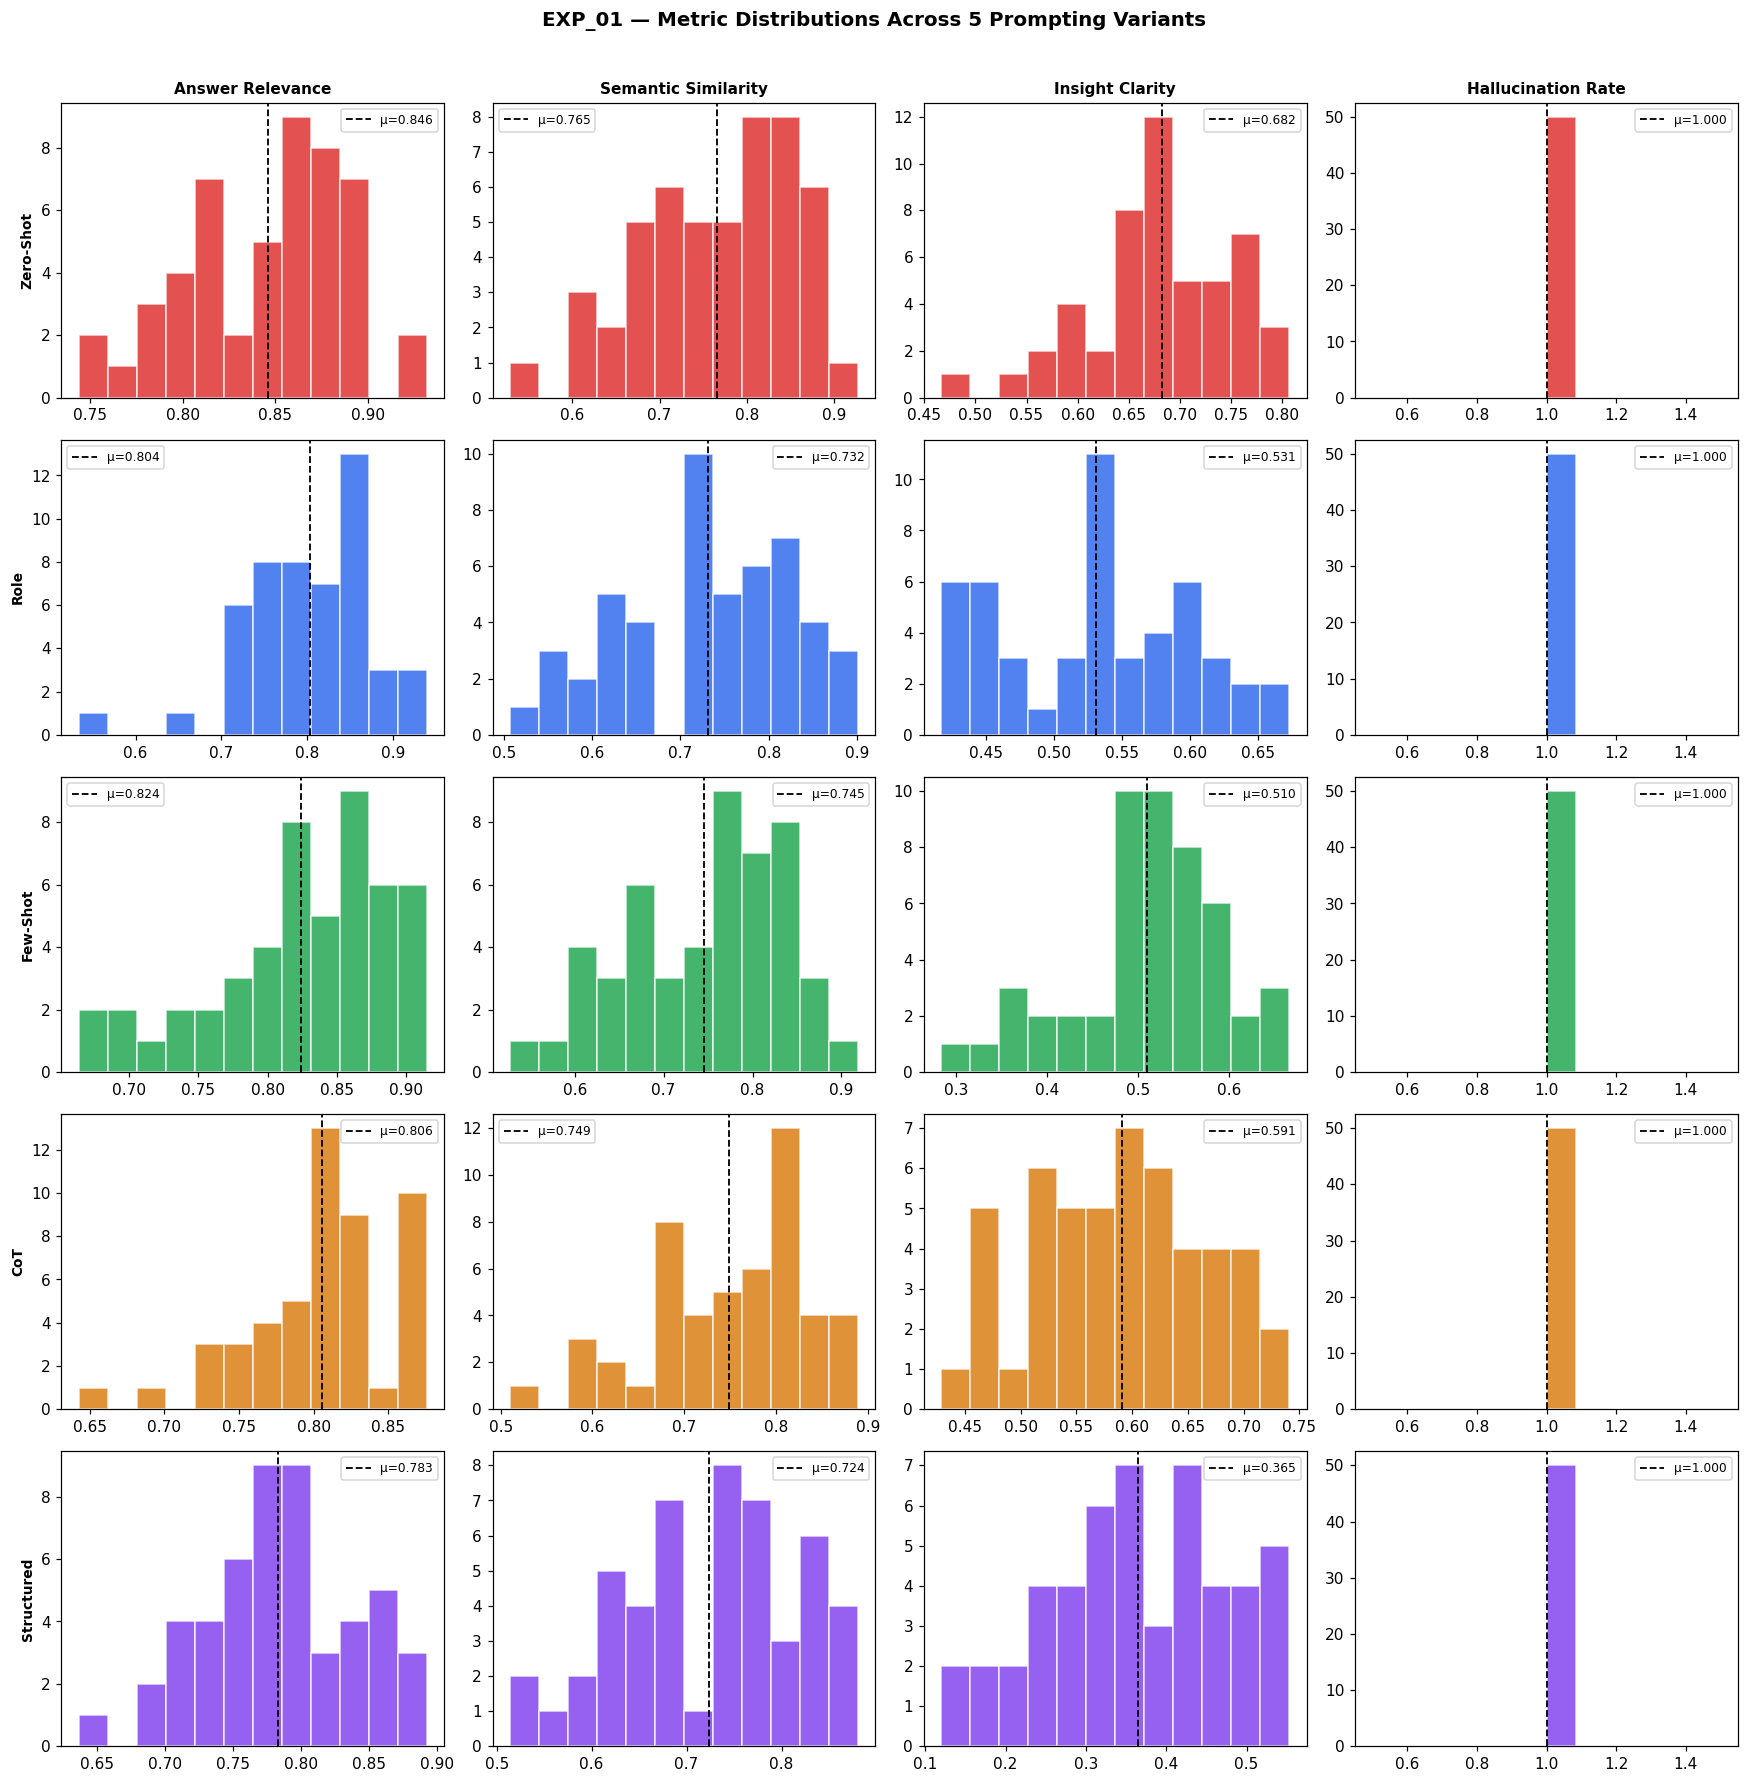

Saved → outputs\experiments\EXP_01_variants_distributions.png


In [11]:
# ── Distribution plots — all 5 variants ──────────────────────────────────────
metric_cols   = ["answer_relevance", "semantic_similarity",
                 "insight_clarity", "hallucination_rate"]
variant_ids   = list(exp01_results.keys())
variant_short = ["Zero-Shot", "Role", "Few-Shot", "CoT", "Structured"]
colors        = ["#DC2626", "#2563EB", "#16A34A", "#D97706", "#7C3AED"]

fig, axes = plt.subplots(
    len(variant_ids), len(metric_cols),
    figsize=(16, 3.2 * len(variant_ids)),
    sharey=False,
)

for row_i, (exp_id, result) in enumerate(exp01_results.items()):
    df = result.to_dataframe()
    for col_j, col in enumerate(metric_cols):
        ax = axes[row_i][col_j]
        if col in df.columns:
            vals = df[col].dropna()
            ax.hist(vals, bins=12, color=colors[row_i], alpha=0.8, edgecolor="white")
            ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1.2,
                       label=f"μ={vals.mean():.3f}")
            ax.legend(fontsize=8)
        if row_i == 0:
            ax.set_title(col.replace("_", " ").title(), fontsize=10, fontweight="bold")
        if col_j == 0:
            ax.set_ylabel(variant_short[row_i], fontsize=9, fontweight="bold")

fig.suptitle("EXP_01 — Metric Distributions Across 5 Prompting Variants",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
save_path = OUTPUTS_DIR / "experiments" / "EXP_01_variants_distributions.png"
plt.savefig(save_path, bbox_inches="tight", dpi=130)
plt.show()
print(f"Saved → {save_path}")

In [12]:
# ── Useful answers summary — all 5 variants ───────────────────────────────────
print(f"{'Variant':<35} {'Useful':>8} {'Total':>7} {'%':>7}  Observation")
print("-" * 100)
for exp_id, result in exp01_results.items():
    df       = result.to_dataframe()
    n_useful = int(df["is_useful"].sum()) if "is_useful" in df.columns else 0
    n_total  = len(df)
    pct      = n_useful / n_total if n_total else 0
    obs      = result.agg_metrics.get("useful_insights_summary", "")
    short    = exp_id.replace("EXP_01", "").replace("_", " ").strip()
    print(f"  {short:<33} {n_useful:>8} {n_total:>7} {pct:>6.1%}  {obs}")
print()

# ── EXP_01E specific: CONFIDENCE label distribution ───────────────────────────
e01e = exp01_results.get("EXP_01E_STRUCTURED")
if e01e:
    conf_json = e01e.agg_metrics.get("confidence_distribution")
    if conf_json:
        import json
        conf_dist = json.loads(conf_json)
        print("EXP_01E Self-Reported Confidence Distribution:")
        for label, count in sorted(conf_dist.items()):
            bar = "█" * count
            print(f"  {label:<10} {bar} ({count})")

Variant                               Useful   Total       %  Observation
----------------------------------------------------------------------------------------------------
  A ZERO SHOT                             50      50 100.0%  50/50 answers passed the usefulness threshold (relevance >= 0.40, >= 20 words). 26/50 answers cited specific numerical values. 50/50 answers included uncertainty/hedging language.
  B ROLE PROMPTING                        50      50 100.0%  50/50 answers passed the usefulness threshold (relevance >= 0.40, >= 20 words). 41/50 answers cited specific numerical values. 0/50 answers included uncertainty/hedging language.
  C FEW SHOT                              50      50 100.0%  50/50 answers passed the usefulness threshold (relevance >= 0.40, >= 20 words). 0/50 answers cited specific numerical values. 0/50 answers included uncertainty/hedging language.
  D CHAIN OF THOUGHT                      50      50 100.0%  50/50 answers passed the usefulness threshol

In [13]:
# ── Sample answers — 2 per variant ───────────────────────────────────────────
for exp_id, result in exp01_results.items():
    df    = result.to_dataframe()
    short = exp_id.replace("EXP_01", "").replace("_", " ").strip()
    print("=" * 70)
    print(f"  {exp_id}  ({short})")
    print("=" * 70)

    for _, row in df.head(2).iterrows():
        answer = str(row.get("answer", ""))
        print(f"\n  Query ID    : {row.get('query_id', '')}")
        print(f"  Question    : {row.get('question', '')[:120]}")
        print(f"  Answer      : {answer[:300]}{'...' if len(answer) > 300 else ''}")
        print(f"  Relevance   : {row.get('answer_relevance', 'N/A')}  "
              f"| Hallucination: {row.get('hallucination_rate', 'N/A')}  "
              f"| Useful: {row.get('is_useful', 'N/A')}")
        obs = row.get("insight_observation", "")
        if obs:
            print(f"  Observation : {obs}")
        print("-" * 70)
    print()

  EXP_01A_ZERO_SHOT  (A ZERO SHOT)

  Query ID    : q000
  Question    : What was the average daily electricity load and peak load recorded across GEFCom zones during the dataset period?
  Answer      : The average daily electricity load across GEFCom zones during the dataset period was approximately 23,000 MW. The peak load recorded was around 30,000 MW, occurring during hot summer afternoons when cooling demand was highest. These values varied slightly across different zones, with some zones expe...
  Relevance   : 0.8783  | Hallucination: 1.0  | Useful: 1
  Observation : Zero-Shot: cited specific numerical values; included hedging language suggesting awareness of uncertainty; answer length: 81 words.
----------------------------------------------------------------------

  Query ID    : q001
  Question    : What is the typical range of minimum and maximum hourly load observed in a single day across the GEFCom zones?
  Answer      : The Global Energy Forecasting Competition (GEFCom) 

In [ ]:
# Reload EXP_01 variants from disk if kernel was restarted
from experiments.exp_01_no_rag_variants import VARIANTS, build_comparison_table

exp01_results = {}
for exp_id in VARIANTS:
    agg_path = EXP_OUTPUTS_DIR / exp_id / "k0" / "agg_metrics.json"
    if agg_path.exists():
        with open(agg_path) as f:
            agg = json.load(f)
        # Wrap in a lightweight container matching ExperimentResult interface
        class _R:
            def __init__(self, agg): self.agg_metrics = agg; self.top_k = 0
        exp01_results[exp_id] = _R(agg)
        print(f"  Loaded {exp_id} | useful={agg.get('pct_useful')}")
    else:
        print(f"  NOT FOUND: {exp_id}")

if exp01_results:
    display(build_comparison_table(exp01_results))

In [ ]:
# ── Initialise + reload any already-completed scores from disk ────────────────
from experiments.ragas_evaluator import load_ragas_scores, summarise_ragas_scores

ragas_exp01 = {}

for exp_id in [
    "EXP_01A_ZERO_SHOT",
    "EXP_01B_ROLE_PROMPTING",
    "EXP_01C_FEW_SHOT",
    "EXP_01D_CHAIN_OF_THOUGHT",
    "EXP_01E_STRUCTURED",
]:
    existing = load_ragas_scores(exp_id, top_k=0, outputs_dir=EXP_OUTPUTS_DIR)
    if existing is not None:
        s = summarise_ragas_scores(existing, exp_id, 0)
        if s["n_valid_faithfulness"] > 0:
            ragas_exp01[exp_id] = existing
            short = exp_id.replace("EXP_01", "").replace("_", " ").strip()
            print(f"  Loaded {short:<30} valid={s['n_valid_faithfulness']}/{s['n_total']}")
        else:
            print(f"  {exp_id} — found but 0 valid rows (needs re-run)")
    else:
        print(f"  {exp_id} — not yet scored")

print(f"\n  {len(ragas_exp01)}/5 variants loaded.")

In [ ]:
print("Scoring EXP_01 Zero-Shot with RAGAS...")
print("(no_rag=True mode — faithfulness + answer_relevancy only, batch_size=5)")
print()

scores_01a = run_ragas_for_experiment(
    exp_id="EXP_01A_ZERO_SHOT",
    top_k=0, golden_df=golden_df,
    outputs_dir=EXP_OUTPUTS_DIR,
    batch_size=2,
)
if scores_01a is not None:
    ragas_exp01["EXP_01A_ZERO_SHOT"] = scores_01a
    s = summarise_ragas_scores(scores_01a, "EXP_01A_ZERO_SHOT", 0)
    print(f"  faithfulness     : {s.get('faithfulness')}")
    print(f"  answer_relevancy : {s.get('answer_relevancy')}")
    print(f"  valid/total      : {s['n_valid_faithfulness']}/{s['n_total']}")

Scoring all EXP_01 variants with RAGAS...
(no_rag=True mode — faithfulness + answer_relevancy only, batch_size=5)

  Scoring EXP_01A_ZERO_SHOT...

  RAGAS: EXP_01A_ZERO_SHOT | K=0
  batch_size=5 | delay=15s | no_rag=True


INFO | experiments.ragas_evaluator | Loaded 50 rows from outputs\experiments\EXP_01A_ZERO_SHOT\k0\query_results.csv
INFO | experiments.ragas_evaluator | Built 50 RAGAS rows (0 skipped).
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO | sentence_transformers.base.model | Loading SentenceTransformer mode

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/tokenizer_config.json "HTTP/1.1 20

  Batch 1/10 | rows 0-4 | Key 2/12


...

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completion

  ✅ 0/50 rows scored so far


INFO | experiments.ragas_evaluator | context_precision/recall set to NaN (No-RAG).



  RAGAS SCORES — EXP_01E_STRUCTURED | K=0
  ⚠️  faithfulness             : nan  (0/50 valid)
  ⚠️  answer_relevancy         : nan  (0/50 valid)
  ⚠️  context_precision        : nan  (0/50 valid)
  ⚠️  context_recall           : nan  (0/50 valid)

    faithfulness     : None
    answer_relevancy : None
    valid/total      : 0/50



In [ ]:
print("Scoring EXP_01 Role Prompting with RAGAS...")
print("(no_rag=True mode — faithfulness + answer_relevancy only, batch_size=5)")
print()

scores_01b = run_ragas_for_experiment(
    exp_id="EXP_01B_ROLE_PROMPTING",
    top_k=0, golden_df=golden_df,
    outputs_dir=EXP_OUTPUTS_DIR,
    batch_size=2, force_rerun=True,
)
if scores_01b is not None:
    ragas_exp01["EXP_01B_ROLE_PROMPTING"] = scores_01b
    s = summarise_ragas_scores(scores_01b, "EXP_01B_ROLE_PROMPTING", 0)
    print(f"  faithfulness     : {s.get('faithfulness')}")
    print(f"  answer_relevancy : {s.get('answer_relevancy')}")
    print(f"  valid/total      : {s['n_valid_faithfulness']}/{s['n_total']}")

In [ ]:
print("Scoring EXP_01 Few Shot Prompting with RAGAS...")
print("(no_rag=True mode — faithfulness + answer_relevancy only, batch_size=5)")
print()

scores_01c = run_ragas_for_experiment(
    exp_id="EXP_01C_FEW_SHOT",
    top_k=0, golden_df=golden_df,
    outputs_dir=EXP_OUTPUTS_DIR,
    batch_size=2, force_rerun=True,
)
if scores_01c is not None:
    ragas_exp01["EXP_01C_FEW_SHOT"] = scores_01c
    s = summarise_ragas_scores(scores_01c, "EXP_01C_FEW_SHOT", 0)
    print(f"  faithfulness     : {s.get('faithfulness')}")
    print(f"  answer_relevancy : {s.get('answer_relevancy')}")
    print(f"  valid/total      : {s['n_valid_faithfulness']}/{s['n_total']}")

In [ ]:
print("Scoring EXP_01 Chain-of-Thought Prompting with RAGAS...")
print("(no_rag=True mode — faithfulness + answer_relevancy only, batch_size=5)")
print()

scores_01d = run_ragas_for_experiment(
    exp_id="EXP_01D_CHAIN_OF_THOUGHT",
    top_k=0, golden_df=golden_df,
    outputs_dir=EXP_OUTPUTS_DIR,
    batch_size=2, force_rerun=True,
)
if scores_01d is not None:
    ragas_exp01["EXP_01D_CHAIN_OF_THOUGHT"] = scores_01d
    s = summarise_ragas_scores(scores_01d, "EXP_01D_CHAIN_OF_THOUGHT", 0)
    print(f"  faithfulness     : {s.get('faithfulness')}")
    print(f"  answer_relevancy : {s.get('answer_relevancy')}")
    print(f"  valid/total      : {s['n_valid_faithfulness']}/{s['n_total']}")

In [ ]:
print("Scoring EXP_01 Structured Prompting with RAGAS...")
print("(no_rag=True mode — faithfulness + answer_relevancy only, batch_size=5)")
print()

scores_01e = run_ragas_for_experiment(
    exp_id="EXP_01E_STRUCTURED",
    top_k=0, golden_df=golden_df,
    outputs_dir=EXP_OUTPUTS_DIR,
    batch_size=2, force_rerun=True,
)
if scores_01e is not None:
    ragas_exp01["EXP_01E_STRUCTURED"] = scores_01e
    s = summarise_ragas_scores(scores_01e, "EXP_01E_STRUCTURED", 0)
    print(f"  faithfulness     : {s.get('faithfulness')}")
    print(f"  answer_relevancy : {s.get('answer_relevancy')}")
    print(f"  valid/total      : {s['n_valid_faithfulness']}/{s['n_total']}")

In [15]:
# ── Table 1 contribution row (EXP_01) ────────────────────────────────────────
# Preview what this experiment contributes to Result Table 1
m = exp01_result.agg_metrics

table1_row = {
    "Experiment":         "EXP_01_NO_RAG_LLM",
    "Correct/Useful (%)":  round(m.get("pct_useful", 0) * 100, 1),
    "Answer Relevance":    m.get("avg_answer_relevance"),
    "Semantic Similarity": m.get("avg_semantic_sim"),
    "Faithfulness Score":  "N/A (no context)",
    "Context Precision":   "N/A",
    "Context Recall":      "N/A",
    "Hallucination Rate %": round(m.get("avg_hallucination_rate", 1.0) * 100, 1),
    "Avg Latency / Query": m.get("avg_latency_sec"),
}

print("EXP_01 contribution to Result Table 1:")
print("-" * 50)
for k, v in table1_row.items():
    print(f"  {k:30s}: {v}")

EXP_01 contribution to Result Table 1:
--------------------------------------------------
  Experiment                    : EXP_01_NO_RAG_LLM
  Correct/Useful (%)            : 100.0
  Answer Relevance              : 0.8408
  Semantic Similarity           : None
  Faithfulness Score            : N/A (no context)
  Context Precision             : N/A
  Context Recall                : N/A
  Hallucination Rate %          : 100.0
  Avg Latency / Query           : 1.444


---
## EXP_02 — Dense RAG (K = 3, 5, 10)

**Objective:** Baseline RAG using FAISS dense retrieval + Llama 3.3 70B.  
**Comparison:** vs EXP_01 — does retrieval reduce hallucination and improve faithfulness?  
**Runs:** 3 passes (K=3, K=5, K=10) — each over all 50 queries.

In [ ]:
from experiments.exp_02_dense_rag import run as run_exp02

print('Running EXP_02_DENSE_RAG at K = 3, 5, 10...')
print(f'  Queries   : {len(QUERIES)}')
print(f'  K values  : {EXP_DEFAULTS["top_k_values"]}')
print(f'  Model     : llama-3.3-70b-versatile (Groq)')
print(f'  Retrieval : FAISS dense (all-MiniLM-L6-v2)')
print()

exp02_results = run_exp02(
    queries=QUERIES,
    k_values=EXP_DEFAULTS['top_k_values'],
    outputs_dir=EXP_OUTPUTS_DIR,
)

print(f'\n  EXP_02 complete — {len(exp02_results)} K-value runs')
for r in exp02_results:
    print(f'   K={r.top_k}  queries={r.total_queries}  errors={r.total_errors}  time={r.total_time_sec:.1f}s')

INFO | config.groq_keys | Loaded 6 Groq API key(s).


Running EXP_02_DENSE_RAG at K = 3, 5, 10...
  Queries   : 50
  K values  : [3, 5, 10]
  Model     : llama-3.3-70b-versatile (Groq)
  Retrieval : FAISS dense (all-MiniLM-L6-v2)



INFO | src.experiments.groq_client | RotatingGroqClient ready — 6 key(s) loaded.
INFO | src.experiments.groq_client | Key pool: 6 available, 6 total. Cooldown=62s  MaxRetries=8
INFO | experiments.exp_02_dense_rag | ─── EXP_02 at K=3 ───
INFO | experiments.exp_02_dense_rag | Loading embedding model and FAISS index...
INFO | src.embedding.embedder | Loading embedding model 'sentence-transformers/all-MiniLM-L6-v2' (runs locally on CPU).
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD ht

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/tokenizer_config.json "HTTP/1.1 20

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO | experiments.runner | [EXP_02_DENSE_RAG | k=10] Complete — 50 queries, 0 errors, 124.4s
INFO | experiments.exp_02_dense_rag | [EXP_02 | k=3] agg_metrics: {'exp_id': 'EXP_02_DENSE_RAG', 'pipeline': 'dense', 'top_k': 3, 'n_queries': 50, 'n_valid': 50, 'n_errors': 0, 'pct_useful': 1.0, 'avg_answer_relevance': 0.7892, 'avg_semantic_similarity': 0.8013, 'avg_faithfulness': None, 'avg_context_precision': None, 'avg_context_recall': None, 'avg_hallucination_rate': 0.2296, 'avg_insight_clarity': 0.5526, 'avg_latency_sec': 2.155, 'avg_recall_at_k': 0.024, 'avg_precision_at_k': 0.04, 'avg_mrr': 0.0567, 'avg_ndcg_at_k': 0.0365, 'avg_relevant_available': 5.14, 'avg_relevant_retrieved': 0.12, 'pct_include_pass': 0.7, 'pct_exclude_pass': 0.98, 'pct_overall_pass': 0.68, 'total_time_sec': 107.78}
INFO | experiments.exp_02_dense_rag | [EXP_02 | k=5] agg_metrics: {'exp_id': 'EXP_02_DENSE_RAG', 'pipeline': 'dense', 'top_k': 5, 'n_queries': 50, 'n_valid': 50, 'n_errors': 0, 'pct_useful': 1.0, 'avg_a


  EXP_02 complete — 3 K-value runs
   K=3  queries=50  errors=0  time=107.8s
   K=5  queries=50  errors=0  time=109.8s
   K=10  queries=50  errors=0  time=124.4s


In [13]:
# ── Aggregate metrics across all K values ────────────────────────────────────
import pandas as pd

print('EXP_02 Aggregate Metrics by K:')
print('-' * 70)

rows = []
for r in exp02_results:
    m = r.agg_metrics
    rows.append({
        'K':                   r.top_k,
        'Recall@K':            m.get('avg_recall_at_k'),
        'Precision@K':         m.get('avg_precision_at_k'),
        'MRR':                 m.get('avg_mrr'),
        'nDCG@K':              m.get('avg_ndcg_at_k'),
        'Answer Relevance':    m.get('avg_answer_relevance'),
        'Semantic Sim':        m.get('avg_semantic_similarity'),
        'Hallucination Rate':  m.get('avg_hallucination_rate'),
        'Include Pass %':      m.get('pct_include_pass'),
        'Exclude Pass %':      m.get('pct_exclude_pass'),
        'Avg Latency (s)':     m.get('avg_latency_sec'),
    })

exp02_summary_df = pd.DataFrame(rows)
display(exp02_summary_df)

EXP_02 Aggregate Metrics by K:
----------------------------------------------------------------------


,K,Recall@K,Precision@K,MRR,nDCG@K,Answer Relevance,Semantic Sim,Hallucination Rate,Include Pass %,Exclude Pass %,Avg Latency (s)
0,3,0.0240,0.04,0.0567,0.0365,0.7892,0.8013,0.2296,0.70,0.98,2.155
1,5,0.0603,0.06,0.0907,0.0513,0.8071,0.8276,0.2043,0.68,0.98,2.196
2,10,0.1447,0.07,0.0986,0.0960,0.8146,0.8284,0.2067,0.72,0.98,2.487


In [14]:
# ── Per-query results for best K ─────────────────────────────────────────────
# Show detailed per-query table for K=5 (middle value)
best_k_result = [r for r in exp02_results if r.top_k == 5][0]
exp02_df = best_k_result.to_dataframe()

display_cols = [
    'query_id', 'question', 'recall_at_k', 'precision_at_k',
    'mrr', 'ndcg_at_k', 'answer_relevance',
    'include_pass', 'exclude_pass', 'latency_sec'
]
display_cols = [c for c in display_cols if c in exp02_df.columns]
print(f'Per-query results (K=5), shape: {exp02_df.shape}')
display(exp02_df[display_cols].head(10))

Per-query results (K=5), shape: (50, 27)


,query_id,question,recall_at_k,precision_at_k,mrr,ndcg_at_k,answer_relevance,include_pass,exclude_pass,latency_sec
0,q000,What was the average daily electricity load an...,0.2,0.2,0.2,0.1312,0.8311,1,1,2.740
1,q001,What is the typical range of minimum and maxim...,0.2,0.2,0.2,0.1312,0.8796,1,1,2.097
2,q002,Which months show the highest average electric...,0.0,0.0,0.0,0.0000,0.7193,1,1,2.347
3,q003,What is the standard deviation of daily load a...,0.0,0.0,0.0,0.0000,0.7824,1,1,2.278
4,q004,What is the total daily energy consumption in ...,0.6,0.6,0.5,0.5296,0.8617,1,1,1.922
5,q005,Describe the typical daily electricity load pa...,0.0,0.0,0.0,0.0000,0.9052,1,1,1.997
6,q006,How does electricity demand change between win...,0.0,0.0,0.0,0.0000,0.7422,0,1,1.726
7,q007,What weekly demand patterns are observed in th...,0.2,0.2,0.5,0.2140,0.7730,1,1,2.279
8,q008,Are there periods of unusually high demand var...,0.0,0.0,0.0,0.0000,0.7245,1,1,2.133
9,q009,How does the weekly mean load evolve across IS...,0.2,0.2,0.5,0.2140,0.8767,1,1,2.708


In [17]:
# ── Retrieval Quality ─────────────────────────────────
print('EXP_02 contribution to Retrieval Quality:')
print('-' * 65)
for r in exp02_results:
    m = r.agg_metrics
    print(f"  Dense RAG (K={r.top_k}):")
    print(f"    Relevant Available : {m.get('avg_relevant_available')}")
    print(f"    Relevant Retrieved : {m.get('avg_relevant_retrieved')}")
    print(f"    Recall@K           : {m.get('avg_recall_at_k')}")
    print(f"    Precision@K        : {m.get('avg_precision_at_k')}")
    print(f"    MRR                : {m.get('avg_mrr')}")
    print(f"    nDCG@K             : {m.get('avg_ndcg_at_k')}")
    print()

EXP_02 contribution to Retrieval Quality:
-----------------------------------------------------------------
  Dense RAG (K=3):
    Relevant Available : 5.14
    Relevant Retrieved : 0.12
    Recall@K           : 0.024
    Precision@K        : 0.04
    MRR                : 0.0567
    nDCG@K             : 0.0365

  Dense RAG (K=5):
    Relevant Available : 5.14
    Relevant Retrieved : 0.3
    Recall@K           : 0.0603
    Precision@K        : 0.06
    MRR                : 0.0907
    nDCG@K             : 0.0513

  Dense RAG (K=10):
    Relevant Available : 5.14
    Relevant Retrieved : 0.7
    Recall@K           : 0.1447
    Precision@K        : 0.07
    MRR                : 0.0986
    nDCG@K             : 0.096



In [ ]:
# ── Reload EXP_02 results from disk ──────────────────────────────────────────
import json
import pandas as pd
from experiments.ragas_evaluator import load_ragas_scores, summarise_ragas_scores, RAGAS_METRIC_COLS

exp02_results = []
ragas_exp02   = {}

for k in [3, 5, 10]:
    agg_path = EXP_OUTPUTS_DIR / "EXP_02_DENSE_RAG" / f"k{k}" / "agg_metrics.json"
    qr_path  = EXP_OUTPUTS_DIR / "EXP_02_DENSE_RAG" / f"k{k}" / "query_results.csv"

    if not agg_path.exists():
        print(f"    EXP_02 K={k} agg_metrics.json not found")
        continue

    with open(agg_path) as f:
        agg = json.load(f)

    qr_df = pd.read_csv(qr_path) if qr_path.exists() else pd.DataFrame()

    # Lightweight container matching ExperimentResult interface
    class _Result:
        def __init__(self, k, agg, df):
            self.top_k       = k
            self.agg_metrics = agg
            self._df         = df
        def to_dataframe(self):
            return self._df

    result = _Result(k, agg, qr_df)
    exp02_results.append(result)

    # Load RAGAS scores
    ragas = load_ragas_scores("EXP_02_DENSE_RAG", k, EXP_OUTPUTS_DIR)
    if ragas is not None:
        ragas_exp02[k] = ragas
        s = summarise_ragas_scores(ragas, "EXP_02_DENSE_RAG", k)
        valid_flag = "  indicative" if s["n_valid_faithfulness"] < 10 else "OK"
        print(f"  {valid_flag} K={k} loaded | "
              f"ans_rel={agg.get('avg_answer_relevance')} | "
              f"halluc={round((agg.get('avg_hallucination_rate') or 0)*100,1)}% | "
              f"faithfulness={s.get('faithfulness')} | "
              f"valid={s['n_valid_faithfulness']}/{s['n_total']}")
    else:
        print(f"  K={k} loaded | "
              f"ans_rel={agg.get('avg_answer_relevance')} | "
              f"halluc={round((agg.get('avg_hallucination_rate') or 0)*100,1)}% | "
              f"RAGAS: not found")

print(f"\n  EXP_02 reload complete — {len(exp02_results)} K-value results loaded")

In [ ]:
# ── Initialise + reload any already-completed scores from disk ────────────────
from experiments.ragas_evaluator import load_ragas_scores, summarise_ragas_scores
ragas_exp02 = {}

for k in [3, 5, 10]:
    existing = load_ragas_scores("EXP_02_DENSE_RAG", top_k=k, outputs_dir=EXP_OUTPUTS_DIR)
    if existing is not None:
        s = summarise_ragas_scores(existing, "EXP_02_DENSE_RAG", k)
        if s["n_valid_faithfulness"] >= 10:
            ragas_exp02[k] = existing
            print(f"  Loaded K={k:<5} valid={s['n_valid_faithfulness']}/{s['n_total']}")
        else:
            print(f"  K={k} found but only {s['n_valid_faithfulness']}/{s['n_total']} valid rows (needs re-run)")
    else:
        print(f"  K={k} not yet scored")

print(f"\n  {len(ragas_exp02)}/3 K-values loaded.")

In [ ]:
scores_02_k3 = run_ragas_for_experiment(
    exp_id="EXP_02_DENSE_RAG",
    top_k=3,
    golden_df=golden_df,
    outputs_dir=EXP_OUTPUTS_DIR,
    batch_size=2,
    force_rerun=False,
)
if scores_02_k3 is not None:
    ragas_exp02[3] = scores_02_k3
    s = summarise_ragas_scores(scores_02_k3, "EXP_02_DENSE_RAG", 3)
    print(f"  faithfulness     : {s.get('faithfulness')}")
    print(f"  answer_relevancy : {s.get('answer_relevancy')}")
    print(f"  context_precision: {s.get('context_precision')}")
    print(f"  context_recall   : {s.get('context_recall')}")
    print(f"  valid/total      : {s['n_valid_faithfulness']}/{s['n_total']}")

In [ ]:
scores_02_k5 = run_ragas_for_experiment(
    exp_id="EXP_02_DENSE_RAG",
    top_k=5,
    golden_df=golden_df,
    outputs_dir=EXP_OUTPUTS_DIR,
    batch_size=2,
    force_rerun=False,
)
if scores_02_k5 is not None:
    ragas_exp02[5] = scores_02_k5
    s = summarise_ragas_scores(scores_02_k5, "EXP_02_DENSE_RAG", 5)
    print(f"  faithfulness     : {s.get('faithfulness')}")
    print(f"  answer_relevancy : {s.get('answer_relevancy')}")
    print(f"  context_precision: {s.get('context_precision')}")
    print(f"  context_recall   : {s.get('context_recall')}")
    print(f"  valid/total      : {s['n_valid_faithfulness']}/{s['n_total']}")

In [ ]:
scores_02_k10 = run_ragas_for_experiment(
    exp_id="EXP_02_DENSE_RAG",
    top_k=10,
    golden_df=golden_df,
    outputs_dir=EXP_OUTPUTS_DIR,
    batch_size=2,
    force_rerun=True,    # force re-run to replace the 3/50 partial scores
)
if scores_02_k10 is not None:
    ragas_exp02[10] = scores_02_k10
    s = summarise_ragas_scores(scores_02_k10, "EXP_02_DENSE_RAG", 10)
    print(f"  faithfulness     : {s.get('faithfulness')}")
    print(f"  answer_relevancy : {s.get('answer_relevancy')}")
    print(f"  context_precision: {s.get('context_precision')}")
    print(f"  context_recall   : {s.get('context_recall')}")
    print(f"  valid/total      : {s['n_valid_faithfulness']}/{s['n_total']}")

---
## EXP_03 — Hybrid RAG

In [6]:
# ── EXP_03: Hybrid RAG (FAISS + BM25) ─────────────────────────────────────
from experiments.exp_03_hybrid_rag import run_exp_03

print("Running EXP_03_HYBRID_RAG at K = 3, 5, 10...")
print(f"  Queries   : 50")
print(f"  K values  : [3, 5, 10]")
print(f"  Model     : {MODELS['groq_rag']} (Groq)")
print(f"  Retrieval : FAISS dense + BM25 sparse (RRF fusion)")

exp03_results = run_exp_03(
    golden_df   = golden_df,
    k_values    = [3, 5, 10],
    outputs_dir = EXP_OUTPUTS_DIR,
)

# ── Summary ────────────────────────────────────────────────────────────────
print("\nEXP_03 Aggregate Metrics by K:")
print("-" * 70)
header = f"{'K':<4} {'Recall@K':<10} {'Precision@K':<13} {'MRR':<8} {'nDCG@K':<10} {'Answer Rel':<12} {'Semantic Sim':<14} {'Halluc %':<10} {'Latency'}"
print(header)
for r in exp03_results:
    m = r.agg_metrics
    print(
        f"{r.top_k:<4} {m.get('avg_recall_at_k', 0):<10.4f} "
        f"{m.get('avg_precision_at_k', 0):<13.4f} "
        f"{m.get('avg_mrr', 0):<8.4f} "
        f"{m.get('avg_ndcg_at_k', 0):<10.4f} "
        f"{m.get('avg_answer_relevance', 0):<12.4f} "
        f"{m.get('avg_semantic_similarity', 0):<14.4f} "
        f"{m.get('avg_hallucination_rate', 0)*100:<10.1f} "
        f"{m.get('avg_latency_sec', 0):.3f}"
    )

INFO | datasets | TensorFlow version 2.18.0 available.
INFO | datasets | JAX version 0.4.38 available.
INFO | config.groq_keys | Loaded 12 Groq API key(s).


Running EXP_03_HYBRID_RAG at K = 3, 5, 10...
  Queries   : 50
  K values  : [3, 5, 10]
  Model     : llama-3.3-70b-versatile (Groq)
  Retrieval : FAISS dense + BM25 sparse (RRF fusion)


INFO | src.experiments.groq_client | RotatingGroqClient ready — 12 key(s) loaded.
INFO | src.experiments.groq_client | Key pool: 12 available, 12 total. Cooldown=62s  MaxRetries=8
INFO | src.embedding.embedder | Loading embedding model 'sentence-transformers/all-MiniLM-L6-v2' (runs locally on CPU).
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sente

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/tokenizer_config.json "HTTP/1.1 20

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO | experiments.runner | [EXP_03_HYBRID_RAG | k=10] Complete — 50 queries, 0 errors, 136.0s
INFO | experiments.exp_03_hybrid_rag | [EXP_03 | k=3] agg_metrics: {'exp_id': 'EXP_03_HYBRID_RAG', 'pipeline': 'hybrid_rag', 'top_k': 3, 'n_queries': 50, 'n_valid': 50, 'n_errors': 0, 'pct_useful': 1.0, 'avg_answer_relevance': 0.8028, 'avg_semantic_similarity': 0.8216, 'avg_faithfulness': None, 'avg_context_precision': None, 'avg_context_recall': None, 'avg_hallucination_rate': 0.1953, 'avg_insight_clarity': 0.504, 'avg_latency_sec': 2.275, 'avg_recall_at_k': 0.0353, 'avg_precision_at_k': 0.06, 'avg_mrr': 0.0633, 'avg_ndcg_at_k': 0.0518, 'avg_relevant_available': 5.14, 'avg_relevant_retrieved': 0.18, 'pct_include_pass': 0.7, 'pct_exclude_pass': 0.92, 'pct_overall_pass': 0.64, 'total_time_sec': 113.82}
INFO | experiments.exp_03_hybrid_rag | [EXP_03 | k=5] agg_metrics: {'exp_id': 'EXP_03_HYBRID_RAG', 'pipeline': 'hybrid_rag', 'top_k': 5, 'n_queries': 50, 'n_valid': 50, 'n_errors': 0, 'pct_usefu


EXP_03 Aggregate Metrics by K:
----------------------------------------------------------------------
K    Recall@K   Precision@K   MRR      nDCG@K     Answer Rel   Semantic Sim   Halluc %   Latency
3    0.0353     0.0600        0.0633   0.0518     0.8028       0.8216         19.5       2.275
5    0.0593     0.0600        0.0837   0.0555     0.8135       0.8351         22.5       2.322
10   0.1097     0.0560        0.1084   0.0823     0.8237       0.8442         21.6       2.721


In [ ]:
# ── Reload EXP_03 results from disk ──────────────────────────────────────────
import json
import pandas as pd

exp03_results = []
ragas_exp03   = {}

for k in [3, 5, 10]:
    agg_path = EXP_OUTPUTS_DIR / "EXP_03_HYBRID_RAG" / f"k{k}" / "agg_metrics.json"
    qr_path  = EXP_OUTPUTS_DIR / "EXP_03_HYBRID_RAG" / f"k{k}" / "query_results.csv"

    if not agg_path.exists():
        print(f"  K={k} agg_metrics.json not found")
        continue

    with open(agg_path) as f:
        agg = json.load(f)

    qr_df = pd.read_csv(qr_path) if qr_path.exists() else pd.DataFrame()

    class _Result:
        def __init__(self, k, agg, df):
            self.top_k       = k
            self.agg_metrics = agg
            self._df         = df
        def to_dataframe(self):
            return self._df

    result = _Result(k, agg, qr_df)
    exp03_results.append(result)
    print(f"  K={k} loaded | "
          f"ans_rel={agg.get('avg_answer_relevance')} | "
          f"halluc={round((agg.get('avg_hallucination_rate') or 0)*100,1)}% | "
          f"queries={agg.get('n_queries')}")

print(f"\n  EXP_03 reload complete — {len(exp03_results)} K-value results loaded")

In [ ]:
# ── Initialise + reload any already-completed RAGAS scores from disk ──────────
from experiments.ragas_evaluator import load_ragas_scores, summarise_ragas_scores
ragas_exp03 = {}

for k in [3, 5, 10]:
    existing = load_ragas_scores("EXP_03_HYBRID_RAG", top_k=k, outputs_dir=EXP_OUTPUTS_DIR)
    if existing is not None:
        s = summarise_ragas_scores(existing, "EXP_03_HYBRID_RAG", k)
        if s["n_valid_faithfulness"] >= 10:
            ragas_exp03[k] = existing
            print(f"  Loaded K={k:<5} valid={s['n_valid_faithfulness']}/{s['n_total']}")
        else:
            print(f"  K={k} found but only {s['n_valid_faithfulness']}/{s['n_total']} valid rows (needs re-run)")
    else:
        print(f"  K={k} not yet scored")

print(f"\n  {len(ragas_exp03)}/3 K-values loaded.")

In [ ]:
scores_03_k3 = run_ragas_for_experiment(
    exp_id="EXP_03_HYBRID_RAG",
    top_k=3,
    golden_df=golden_df,
    outputs_dir=EXP_OUTPUTS_DIR,
    batch_size=2,
    force_rerun=False,
)
if scores_03_k3 is not None:
    ragas_exp03[3] = scores_03_k3
    s = summarise_ragas_scores(scores_03_k3, "EXP_03_HYBRID_RAG", 3)
    print(f"  faithfulness     : {s.get('faithfulness')}")
    print(f"  answer_relevancy : {s.get('answer_relevancy')}")
    print(f"  context_precision: {s.get('context_precision')}")
    print(f"  context_recall   : {s.get('context_recall')}")
    print(f"  valid/total      : {s['n_valid_faithfulness']}/{s['n_total']}")

In [ ]:
scores_03_k5 = run_ragas_for_experiment(
    exp_id="EXP_03_HYBRID_RAG",
    top_k=5,
    golden_df=golden_df,
    outputs_dir=EXP_OUTPUTS_DIR,
    batch_size=2,
    force_rerun=True,
)
if scores_03_k5 is not None:
    ragas_exp03[5] = scores_03_k5
    s = summarise_ragas_scores(scores_03_k5, "EXP_03_HYBRID_RAG", 5)
    print(f"  faithfulness     : {s.get('faithfulness')}")
    print(f"  answer_relevancy : {s.get('answer_relevancy')}")
    print(f"  context_precision: {s.get('context_precision')}")
    print(f"  context_recall   : {s.get('context_recall')}")
    print(f"  valid/total      : {s['n_valid_faithfulness']}/{s['n_total']}")

In [ ]:
scores_03_k10 = run_ragas_for_experiment(
    exp_id="EXP_03_HYBRID_RAG",
    top_k=10,
    golden_df=golden_df,
    outputs_dir=EXP_OUTPUTS_DIR,
    batch_size=2,
    force_rerun=True,
)
if scores_03_k10 is not None:
    ragas_exp03[10] = scores_03_k10
    s = summarise_ragas_scores(scores_03_k10, "EXP_03_HYBRID_RAG", 10)
    print(f"  faithfulness     : {s.get('faithfulness')}")
    print(f"  answer_relevancy : {s.get('answer_relevancy')}")
    print(f"  context_precision: {s.get('context_precision')}")
    print(f"  context_recall   : {s.get('context_recall')}")
    print(f"  valid/total      : {s['n_valid_faithfulness']}/{s['n_total']}")

---
## EXP_04 — Hierarchical RAG  *(placeholder)*

In [ ]:
print("EXP_04 placeholder — build experiments/exp_04_hierarchical_rag.py next")

---
## EXP_05–07 — Novelty 1: Attribution  *(placeholders)*

In [ ]:
print("EXP_05–07 placeholders — Novelty 1 (Attribution) coming next")

---
## EXP_08–09 — Novelty 2: Query Difficulty  *(placeholders)*

In [ ]:
print("EXP_08–09 placeholders — Novelty 2 (Difficulty) coming next")

---
## EXP_10 — Final Comparison  *(placeholder)*

In [ ]:
print("EXP_10 placeholder — Final comparison after all experiments complete")